# Part 1, MZI design

We start by importing all the libraries, we will use

In [15]:
import numpy as np
import gdsfactory as gf
from kfactory import port

gf.gpdk.PDK.activate()

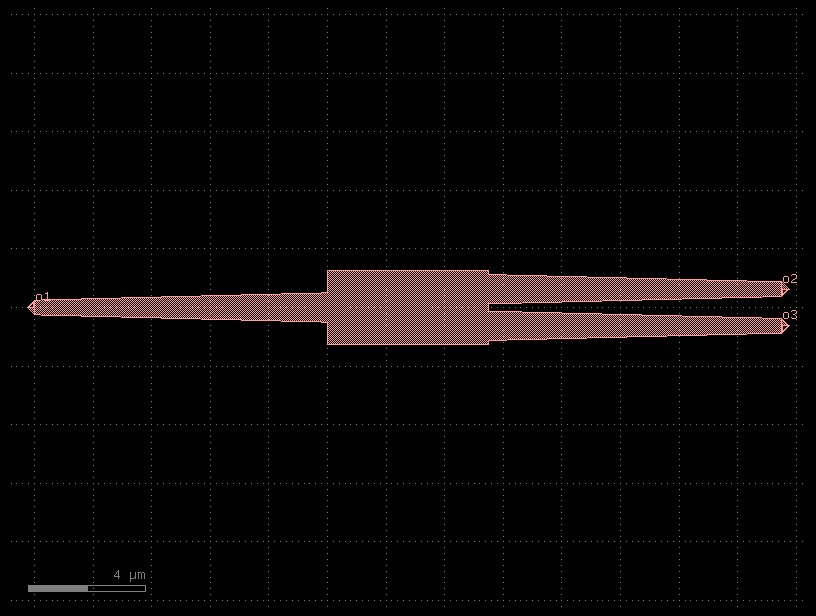

In [16]:
c = gf.components.mmi1x2(width_taper=1, length_taper=10, length_mmi=5.5, width_mmi=2.5, gap_mmi=0.25, cross_section='strip').copy()
c.draw_ports()
c.plot()
c.show()

# //////  FIN DE LA FUNCIÓN MZI#### Start defining the MZI function.

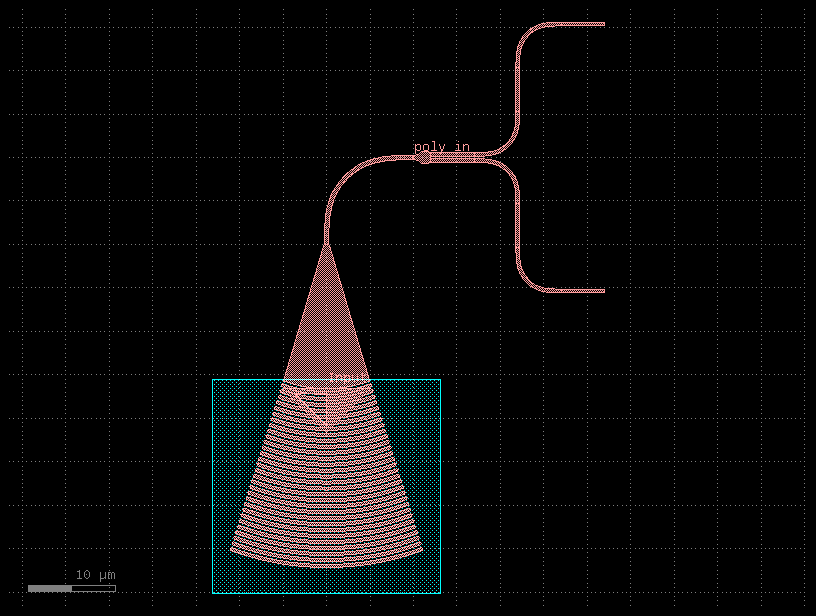

In [114]:

def Y_splitter (widths = [0.5, 0.5, 0.6, 0.7, 0.9,1.26, 1.4, 1.4, 1.4, 1.4,1.31, 1.2, 1.2],
                splitter_len = 2.0,
                layer = (1,0),
                taper_length = 5.0,
                taper_width_in = 0.5,
                taper_width_out = 0.42, ):
    c = gf.Component()

    n = len(widths)
    dx = splitter_len / n

    # x positions
    xs = np.linspace(0, splitter_len, n)

    # Upper and lower boundaries
    y_top = np.array(widths) / 2
    y_bot = -y_top

    # Build central polygon
    points = []

    # top boundary (left → right)
    for x, y in zip(xs, y_top):
        points.append((x, y))

    # bottom boundary (right → left)
    for x, y in zip(xs[::-1], y_bot[::-1]):
        points.append((x, y))

    c.add_polygon(points, layer=layer)

    # --- Split into two arms at the end ---
    split_gap = widths[-1] - taper_width_in

    # Upper arm
    upper_taper = gf.components.taper(
        length=taper_length,
        width1=taper_width_in,
        width2=taper_width_out,
        layer=layer,
    )
    t1 = c.add_ref(upper_taper)
    t1.move((taper_length, split_gap / 2))

    # Lower arm
    lower_taper = gf.components.taper(
        length=taper_length,
        width1=taper_width_in,
        width2=taper_width_out,
        layer=layer,
    )
    t2 = c.add_ref(lower_taper)
    t2.move((taper_length, -split_gap / 2))

    c.add_port(
        name="poly_in",
        center=(0, 0),
        width=taper_width_in,
        orientation=180,
        layer=layer,
    )


# def MZI_generator(wavelength = 1.55, core_material, cladd_material ,neff, FSR = 20, width = 0.420, thick = 0.22):

# //////  INICIO DE LA FUNCION MZI
# We define an sketch where we will place the components
c = gf.Component()


# ////////////////////////////////////////////////////

# What follows is a bend to place the MZI horizontal


# Base bend (by default: left → up, or depends on PDK)
bend = gf.components.bend_euler(width=0.5,radius=10, angle=-90)

# Add reference
ref_bend = c.add_ref(bend)



# ////////////////////////////////////////////////////

# What follows is a bend to place the MZI horizontal

# Default widths from paper (µm)
widths = [
    0.5, 0.5, 0.6, 0.7, 0.9,
    1.26, 1.4, 1.4, 1.4, 1.4,
    1.31, 1.2, 1.2
]

n = len(widths)
dx = 2.0 / n

# x positions
xs = np.linspace(0, 2.0, n)

# Upper and lower boundaries
y_top = np.array(widths) / 2
y_bot = -y_top

# Build central polygon
points = []

# top boundary (left → right)
for x, y in zip(xs, y_top):
    points.append((x, y))

# bottom boundary (right → left)
for x, y in zip(xs[::-1], y_bot[::-1]):
    points.append((x, y))

c.add_polygon(points, layer=(1,0))

# --- Split into two arms at the end ---
split_gap = widths[-1] - 0.5

# Upper arm
upper_taper = gf.components.taper(
    length=5.0,
    width1=0.5,
    width2=0.42,
    layer=(1,0),
)
t1 = c.add_ref(upper_taper)
t1.move((2.0, split_gap / 2))

# Lower arm
lower_taper = gf.components.taper(
    length=5.0,
    width1=0.5,
    width2=0.42,
    layer=(1,0),
)
t2 = c.add_ref(lower_taper)
t2.move((2.0, -split_gap / 2))

c.add_port(
    name="poly_in",
    center=(0, 0),
    width=0.5,
    orientation=180,
    layer=(1,0),
)

## At the end we connect:

ref_bend.connect("o2",c.ports["poly_in"])


# ////////////////////////////////////////////////////

# What follows is to set the in and out grating couplers

# We define the input and output gratings for now, the input need to be rotated and port-renamed
gr_coupler_output = gf.components.grating_coupler_elliptical(polarization='te',
                                             taper_length=16.6,
                                             taper_angle=40,
                                             wavelength=1.554,
                                             fiber_angle=15,
                                             grating_line_width=0.343,
                                             neff=2.638, nclad=1.443,
                                             n_periods=30,
                                             big_last_tooth=False,
                                             layer_slab='SLAB150',
                                             slab_xmin=-1,
                                             slab_offset=2,
                                             spiked=True,
                                             cross_section='strip').copy()
#creation of components
gr_coupler_output = gr_coupler_output.rotate(-90)
gr_coupler_input = gr_coupler_output.copy()

#Referencing
ref_gr_coupler_input = c.add_ref(gr_coupler_input)


ref_gr_coupler_input.connect("o1",ref_bend.ports["o1"])

c.add_port(name="Input", port=ref_gr_coupler_input.ports["o2"])



# ////////////////////////////////////////////////////

# What follows is to design the two arms

# Common parameters
wg_width = 0.42


# --------------------------------------------------
# 2. First bend (turn upwards)
# --------------------------------------------------
bend1 = gf.components.bend_euler(radius=5, width=wg_width)
b1_ref = c.add_ref(bend1)

# Connect to straight
b1_ref.connect("o1", t1.ports["o2"])

# Mirrored bend
b1_mirror = c.add_ref(bend1)
b1_mirror.mirror(p1=(0, 0), p2=(1, 0))

b1_mirror.connect("o1", t2.ports["o2"])


str_wg1 =  gf.components.straight(length=5, width=wg_width)

str_wg1_ref = c.add_ref(str_wg1)

# Connect to straight
str_wg1_ref.connect("o1", b1_ref.ports["o2"])

# Mirrored straight
str_wg1_ref_mirror = c.add_ref(str_wg1)
str_wg1_ref_mirror.mirror(p1=(0, 0), p2=(1, 0))

str_wg1_ref_mirror.connect("o1", b1_mirror.ports["o2"])



# --------------------------------------------------
# 3. Second bend (turn right again)
# --------------------------------------------------
bend2 = gf.components.bend_euler(radius=5, width=wg_width,angle=-90)
b2_ref = c.add_ref(bend2)

# Connect to first bend
b2_ref.connect("o1", str_wg1_ref.ports["o2"])

# Mirrored version
b2_mirror = c.add_ref(bend2)
b2_mirror.mirror(p1=(0, 0), p2=(1, 0))
b2_mirror.connect("o1", str_wg1_ref_mirror.ports["o2"])

# --------------------------------------------------
# 4. Long straight waveguide
# --------------------------------------------------
long_straight = gf.components.straight(length=5, width=wg_width)
ls_ref = c.add_ref(long_straight)

# Connect to second bend
ls_ref.connect("o1", b2_ref.ports["o2"])

# Mirrored version
ls_mirror = c.add_ref(long_straight)
ls_mirror.mirror(p1=(0, 0), p2=(0, 1))
ls_mirror.connect("o1", b2_mirror.ports["o2"])


# //////  FIN DE LA FUNCIÓN MZI


c.draw_ports()
c.plot()
c.show()
